# Case Study 8: Smart Education Analytics and Student Performance Prediction System

This notebook solves Q1 to Q7 using the datasets available in the project `data/` folder:
`assessments.csv`, `courses.csv`, `studentAssessment.csv`, `studentInfo.csv`, `studentRegistration.csv`, `studentVle.csv`, and `vle.csv`.

Note: the provided files do not contain separate attendance or placement datasets. For the requested attendance analysis, `studentVle.csv` click activity is used as an online attendance/engagement proxy. For placement trends, the available `final_result` academic outcome is used as the closest outcome proxy.

## Q1. Spark Initialization and Data Loading

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Could not find the project data/ folder. Run from the project root or notebooks folder.")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MPL_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
MPL_CACHE_DIR.mkdir(exist_ok=True)

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["MPLCONFIGDIR"] = str(MPL_CACHE_DIR)

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("SmartEducationAnalyticsQ1toQ7")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Python executable:", sys.executable)
print("Spark version:", spark.version)
print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

Python executable: C:\Users\15dha\OneDrive\Desktop\case_study\.venv310\Scripts\python.exe
Spark version: 3.5.7
Project root: C:\Users\15dha\OneDrive\Desktop\case_study
Data folder: C:\Users\15dha\OneDrive\Desktop\case_study\data


In [2]:
def load_csv(file_name):
    return (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .option("nullValue", "")
        .csv(str(DATA_DIR / file_name))
    )

assessments = load_csv("assessments.csv")
courses = load_csv("courses.csv")
student_assessment = load_csv("studentAssessment.csv")
student_info = load_csv("studentInfo.csv")
student_registration = load_csv("studentRegistration.csv")
vle = load_csv("vle.csv")
student_vle = load_csv("studentVle.csv").repartition(8)

frames = {
    "assessments": assessments,
    "courses": courses,
    "student_assessment": student_assessment,
    "student_info": student_info,
    "student_registration": student_registration,
    "vle": vle,
    "student_vle": student_vle,
}

summary = []
for name, df in frames.items():
    summary.append((name, df.count(), len(df.columns)))

spark.createDataFrame(summary, ["dataset", "rows", "columns"]).show(truncate=False)

for name, df in frames.items():
    print(f"\n{name} schema")
    df.printSchema()

+--------------------+--------+-------+
|dataset             |rows    |columns|
+--------------------+--------+-------+
|assessments         |206     |6      |
|courses             |22      |3      |
|student_assessment  |173912  |5      |
|student_info        |32593   |12     |
|student_registration|32593   |5      |
|vle                 |6364    |6      |
|student_vle         |10655280|6      |
+--------------------+--------+-------+


assessments schema
root
 |-- code_module: string (nullable = true)
 |-- code_presentation: string (nullable = true)
 |-- id_assessment: integer (nullable = true)
 |-- assessment_type: string (nullable = true)
 |-- date: integer (nullable = true)
 |-- weight: double (nullable = true)


courses schema
root
 |-- code_module: string (nullable = true)
 |-- code_presentation: string (nullable = true)
 |-- module_presentation_length: integer (nullable = true)


student_assessment schema
root
 |-- id_assessment: integer (nullable = true)
 |-- id_student: integ

In [3]:
print("Sample student information")
student_info.show(5, truncate=False)

print("Sample VLE activity")
student_vle.show(5, truncate=False)

Sample student information


+-----------+-----------------+----------+------+--------------------+---------------------+--------+--------+--------------------+---------------+----------+------------+
|code_module|code_presentation|id_student|gender|region              |highest_education    |imd_band|age_band|num_of_prev_attempts|studied_credits|disability|final_result|
+-----------+-----------------+----------+------+--------------------+---------------------+--------+--------+--------------------+---------------+----------+------------+
|AAA        |2013J            |11391     |M     |East Anglian Region |HE Qualification     |90-100% |55<=    |0                   |240            |N         |Pass        |
|AAA        |2013J            |28400     |F     |Scotland            |HE Qualification     |20-30%  |35-55   |0                   |60             |N         |Pass        |
|AAA        |2013J            |30268     |F     |North Western Region|A Level or Equivalent|30-40%  |35-55   |0                   |60       

+-----------+-----------------+----------+-------+----+---------+
|code_module|code_presentation|id_student|id_site|date|sum_click|
+-----------+-----------------+----------+-------+----+---------+
|AAA        |2013J            |305386    |546614 |159 |3        |
|BBB        |2013B            |538221    |542807 |141 |4        |
|BBB        |2013J            |523928    |703737 |94  |2        |
|AAA        |2013J            |262934    |546614 |127 |4        |
|AAA        |2013J            |383254    |546614 |12  |1        |
+-----------+-----------------+----------+-------+----+---------+
only showing top 5 rows



## Q2. RDD Implementation

In [4]:
info_rdd = student_info.rdd

result_counts = (
    info_rdd
    .map(lambda r: (r["final_result"], 1))
    .reduceByKey(lambda a, b: a + b)
    .collect()
)

pass_students = (
    info_rdd
    .filter(lambda r: r["final_result"] in ["Pass", "Distinction"])
    .map(lambda r: (r["id_student"], r["code_module"], r["code_presentation"], r["final_result"]))
    .take(10)
)

region_counts = (
    info_rdd
    .map(lambda r: (r["region"], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[1], ascending=False)
    .take(10)
)

print("Final result counts from RDD action:")
print(result_counts)

print("\nFirst 10 pass/distinction students from RDD transformation:")
print(pass_students)

print("\nTop 10 regions by student count:")
print(region_counts)

Final result counts from RDD action:
[('Pass', 12361), ('Withdrawn', 10156), ('Fail', 7052), ('Distinction', 3024)]

First 10 pass/distinction students from RDD transformation:
[(11391, 'AAA', '2013J', 'Pass'), (28400, 'AAA', '2013J', 'Pass'), (31604, 'AAA', '2013J', 'Pass'), (32885, 'AAA', '2013J', 'Pass'), (38053, 'AAA', '2013J', 'Pass'), (45462, 'AAA', '2013J', 'Pass'), (45642, 'AAA', '2013J', 'Pass'), (52130, 'AAA', '2013J', 'Pass'), (53025, 'AAA', '2013J', 'Pass'), (57506, 'AAA', '2013J', 'Pass')]

Top 10 regions by student count:
[('Scotland', 3446), ('East Anglian Region', 3340), ('London Region', 3216), ('South Region', 3092), ('North Western Region', 2906), ('West Midlands Region', 2582), ('South West Region', 2436), ('East Midlands Region', 2365), ('South East Region', 2111), ('Wales', 2086)]


## Q3. Key-Value Operations and Persistence

In [5]:
score_pairs = (
    student_assessment
    .select("id_assessment", "score")
    .na.drop(subset=["id_assessment", "score"])
    .rdd
    .map(lambda r: (int(r["id_assessment"]), (float(r["score"]), 1)))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

assessment_type_pairs = (
    assessments
    .select("id_assessment", "code_module", "assessment_type", "weight")
    .rdd
    .map(lambda r: (int(r["id_assessment"]), (r["code_module"], r["assessment_type"], r["weight"])))
)

avg_score_by_assessment = score_pairs.reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1])
).mapValues(lambda x: round(x[0] / x[1], 2))

joined_assessment_scores = avg_score_by_assessment.join(assessment_type_pairs)

print("Average score by assessment joined with assessment metadata:")
print(joined_assessment_scores.take(10))

student_clicks = (
    student_vle
    .groupBy("code_module", "code_presentation", "id_student")
    .agg(F.sum("sum_click").alias("total_clicks"), F.count("*").alias("activity_rows"))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("Persisted student click summary rows:", student_clicks.count())
student_clicks.orderBy(F.desc("total_clicks")).show(10, truncate=False)
print("Student clicks storage level:", student_clicks.storageLevel)

Average score by assessment joined with assessment metadata:


[(1752, (70.31, ('AAA', 'TMA', 10.0))), (1758, (69.26, ('AAA', 'TMA', 10.0))), (14988, (72.73, ('BBB', 'TMA', 18.0))), (14994, (86.95, ('BBB', 'CMA', 1.0))), (15000, (72.43, ('BBB', 'TMA', 18.0))), (15006, (86.42, ('BBB', 'CMA', 1.0))), (15012, (73.29, ('BBB', 'TMA', 18.0))), (15018, (85.91, ('BBB', 'CMA', 1.0))), (15024, (69.58, ('BBB', 'TMA', 35.0))), (24282, (74.52, ('CCC', 'TMA', 9.0)))]


Persisted student click summary rows: 29228


+-----------+-----------------+----------+------------+-------------+
|code_module|code_presentation|id_student|total_clicks|activity_rows|
+-----------+-----------------+----------+------------+-------------+
|CCC        |2014J            |80868     |24139       |2953         |
|FFF        |2013B            |517269    |21123       |3078         |
|CCC        |2014J            |611417    |20391       |1923         |
|FFF        |2013J            |368315    |19734       |2363         |
|FFF        |2014J            |583487    |19461       |2747         |
|FFF        |2014J            |644361    |19415       |2806         |
|FFF        |2013J            |898594    |19126       |2878         |
|FFF        |2013B            |560431    |18039       |2833         |
|FFF        |2014J            |630905    |17825       |2753         |
|FFF        |2014J            |617580    |17481       |2107         |
+-----------+-----------------+----------+------------+-------------+
only showing top 10 

## Q4. Spark DataFrame Operations

In [6]:
keys = ["code_module", "code_presentation", "id_student"]
course_keys = ["code_module", "code_presentation"]

assessment_fact = (
    student_assessment
    .join(assessments, on="id_assessment", how="left")
    .withColumn("score", F.col("score").cast("double"))
    .withColumn("weight", F.col("weight").cast("double"))
)

student_base = (
    student_info
    .join(student_registration, on=keys, how="left")
    .join(courses, on=course_keys, how="left")
)

score_by_student = (
    assessment_fact
    .groupBy(*keys)
    .agg(
        F.avg("score").alias("avg_score"),
        (F.sum(F.col("score") * F.col("weight")) / F.sum("weight")).alias("weighted_avg_score"),
        F.count("id_assessment").alias("assessments_submitted"),
        F.sum("is_banked").alias("banked_assessments"),
    )
)

click_by_student = (
    student_clicks
    .groupBy(*keys)
    .agg(
        F.sum("total_clicks").alias("total_clicks"),
        F.sum("activity_rows").alias("activity_rows"),
    )
)

student_profile = (
    student_base
    .join(score_by_student, on=keys, how="left")
    .join(click_by_student, on=keys, how="left")
    .fillna({
        "avg_score": 0.0,
        "weighted_avg_score": 0.0,
        "assessments_submitted": 0,
        "banked_assessments": 0,
        "total_clicks": 0,
        "activity_rows": 0,
    })
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("Student profile rows:", student_profile.count())
student_profile.select(
    "code_module", "code_presentation", "id_student", "gender", "highest_education",
    "num_of_prev_attempts", "studied_credits", "avg_score", "weighted_avg_score",
    "total_clicks", "final_result"
).show(10, truncate=False)

print("Average score and clicks by module")
student_profile.groupBy("code_module").agg(
    F.countDistinct("id_student").alias("students"),
    F.round(F.avg("avg_score"), 2).alias("avg_score"),
    F.round(F.avg("total_clicks"), 2).alias("avg_clicks")
).orderBy("code_module").show(truncate=False)

Student profile rows: 32593


+-----------+-----------------+----------+------+---------------------+--------------------+---------------+---------+------------------+------------+------------+
|code_module|code_presentation|id_student|gender|highest_education    |num_of_prev_attempts|studied_credits|avg_score|weighted_avg_score|total_clicks|final_result|
+-----------+-----------------+----------+------+---------------------+--------------------+---------------+---------+------------------+------------+------------+
|AAA        |2013J            |11391     |M     |HE Qualification     |0                   |240            |82.0     |82.4              |934         |Pass        |
|AAA        |2013J            |32885     |F     |Lower Than A Level   |0                   |60             |54.4     |55.0              |1034        |Pass        |
|AAA        |2013J            |52130     |F     |A Level or Equivalent|0                   |90             |71.4     |71.2              |1894        |Pass        |
|AAA        |201

+-----------+--------+---------+----------+
|code_module|students|avg_score|avg_clicks|
+-----------+--------+---------+----------+
|AAA        |712     |64.27    |1666.65   |
|BBB        |7692    |56.32    |661.8     |
|CCC        |4251    |51.66    |1055.97   |
|DDD        |5848    |53.22    |881.71    |
|EEE        |2859    |62.71    |1357.95   |
|FFF        |7397    |61.21    |2266.67   |
|GGG        |2525    |64.47    |526.39    |
+-----------+--------+---------+----------+



## Q5. Exploratory Data Analysis and Spark SQL

In [7]:
assessments.createOrReplaceTempView("assessments")
courses.createOrReplaceTempView("courses")
student_assessment.createOrReplaceTempView("student_assessment")
student_info.createOrReplaceTempView("student_info")
student_registration.createOrReplaceTempView("student_registration")
vle.createOrReplaceTempView("vle")
student_vle.createOrReplaceTempView("student_vle")
assessment_fact.createOrReplaceTempView("assessment_fact")
student_profile.createOrReplaceTempView("student_profile")

print("Missing values by dataset")
for name, df in frames.items():
    null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
    print(f"\n{name}")
    df.select(null_exprs).show(truncate=False)

print("Duplicate key checks")
student_info.groupBy(*keys).count().filter("count > 1").show(5)
student_registration.groupBy(*keys).count().filter("count > 1").show(5)

Missing values by dataset



assessments


+-----------+-----------------+-------------+---------------+----+------+
|code_module|code_presentation|id_assessment|assessment_type|date|weight|
+-----------+-----------------+-------------+---------------+----+------+
|0          |0                |0            |0              |11  |0     |
+-----------+-----------------+-------------+---------------+----+------+


courses


+-----------+-----------------+--------------------------+
|code_module|code_presentation|module_presentation_length|
+-----------+-----------------+--------------------------+
|0          |0                |0                         |
+-----------+-----------------+--------------------------+


student_assessment


+-------------+----------+--------------+---------+-----+
|id_assessment|id_student|date_submitted|is_banked|score|
+-------------+----------+--------------+---------+-----+
|0            |0         |0             |0        |173  |
+-------------+----------+--------------+---------+-----+


student_info


...

+-----------+-----------------+----------+-----------------+-------------------+
|code_module|code_presentation|id_student|date_registration|date_unregistration|
+-----------+-----------------+----------+-----------------+-------------------+
|0          |0                |0         |45               |22521              |
+-----------+-----------------+----------+-----------------+-------------------+


vle


+-------+-----------+-----------------+-------------+---------+-------+
|id_site|code_module|code_presentation|activity_type|week_from|week_to|
+-------+-----------+-----------------+-------------+---------+-------+
|0      |0          |0                |0            |5243     |5243   |
+-------+-----------+-----------------+-------------+---------+-------+


student_vle


+-----------+-----------------+----------+-------+----+---------+
|code_module|code_presentation|id_student|id_site|date|sum_click|
+-----------+-----------------+----------+-------+----+---------+
|0          |0                |0         |0      |0   |0        |
+-----------+-----------------+----------+-------+----+---------+

Duplicate key checks


+-----------+-----------------+----------+-----+
|code_module|code_presentation|id_student|count|
+-----------+-----------------+----------+-----+
+-----------+-----------------+----------+-----+



+-----------+-----------------+----------+-----+
|code_module|code_presentation|id_student|count|
+-----------+-----------------+----------+-----+
+-----------+-----------------+----------+-----+



In [8]:
print("1. Online attendance/engagement pattern using VLE clicks")
spark.sql("""
    SELECT
        code_module,
        code_presentation,
        FLOOR(date / 7) + 1 AS study_week,
        SUM(sum_click) AS total_clicks,
        COUNT(DISTINCT id_student) AS active_students,
        ROUND(SUM(sum_click) / COUNT(DISTINCT id_student), 2) AS clicks_per_active_student
    FROM student_vle
    WHERE date BETWEEN 0 AND 270
    GROUP BY code_module, code_presentation, FLOOR(date / 7) + 1
    ORDER BY code_module, code_presentation, study_week
    LIMIT 25
""").show(25, truncate=False)

print("2. Subject-wise performance")
spark.sql("""
    SELECT
        code_module,
        COUNT(DISTINCT id_student) AS assessed_students,
        ROUND(AVG(score), 2) AS avg_score,
        ROUND(MIN(score), 2) AS min_score,
        ROUND(MAX(score), 2) AS max_score
    FROM assessment_fact
    WHERE score IS NOT NULL
    GROUP BY code_module
    ORDER BY avg_score DESC
""").show(truncate=False)

print("3. Top-performing students")
spark.sql("""
    SELECT
        id_student,
        code_module,
        code_presentation,
        final_result,
        ROUND(weighted_avg_score, 2) AS weighted_avg_score,
        ROUND(avg_score, 2) AS avg_score,
        total_clicks,
        assessments_submitted
    FROM student_profile
    ORDER BY weighted_avg_score DESC, avg_score DESC, total_clicks DESC
    LIMIT 20
""").show(20, truncate=False)

print("4. Placement trend proxy using available final academic outcome")
spark.sql("""
    SELECT
        highest_education,
        final_result,
        COUNT(*) AS students,
        ROUND(AVG(total_clicks), 2) AS avg_clicks,
        ROUND(AVG(weighted_avg_score), 2) AS avg_weighted_score
    FROM student_profile
    GROUP BY highest_education, final_result
    ORDER BY highest_education, students DESC
""").show(50, truncate=False)

print("5. Semester-wise academic report")
spark.sql("""
    SELECT
        code_presentation,
        code_module,
        COUNT(*) AS students,
        SUM(CASE WHEN final_result = 'Distinction' THEN 1 ELSE 0 END) AS distinction_count,
        SUM(CASE WHEN final_result = 'Pass' THEN 1 ELSE 0 END) AS pass_count,
        SUM(CASE WHEN final_result = 'Fail' THEN 1 ELSE 0 END) AS fail_count,
        SUM(CASE WHEN final_result = 'Withdrawn' THEN 1 ELSE 0 END) AS withdrawn_count,
        ROUND(AVG(weighted_avg_score), 2) AS avg_weighted_score,
        ROUND(AVG(total_clicks), 2) AS avg_clicks
    FROM student_profile
    GROUP BY code_presentation, code_module
    ORDER BY code_presentation, code_module
""").show(50, truncate=False)

1. Online attendance/engagement pattern using VLE clicks


+-----------+-----------------+----------+------------+---------------+-------------------------+
|code_module|code_presentation|study_week|total_clicks|active_students|clicks_per_active_student|
+-----------+-----------------+----------+------------+---------------+-------------------------+
|AAA        |2013J            |1         |33960       |337            |100.77                   |
|AAA        |2013J            |2         |38066       |341            |111.63                   |
|AAA        |2013J            |3         |44171       |357            |123.73                   |
|AAA        |2013J            |4         |23292       |305            |76.37                    |
|AAA        |2013J            |5         |19847       |315            |63.01                    |
|AAA        |2013J            |6         |20532       |312            |65.81                    |
|AAA        |2013J            |7         |19382       |318            |60.95                    |
|AAA        |2013J  

+-----------+-----------------+---------+---------+---------+
|code_module|assessed_students|avg_score|min_score|max_score|
+-----------+-----------------+---------+---------+---------+
|EEE        |2267             |81.18    |0.0      |100.0    |
|GGG        |2104             |79.7     |0.0      |100.0    |
|FFF        |6052             |77.71    |0.0      |100.0    |
|BBB        |5955             |76.71    |0.0      |100.0    |
|CCC        |3317             |73.26    |0.0      |100.0    |
|DDD        |4695             |70.09    |0.0      |100.0    |
|AAA        |677              |69.03    |0.0      |98.0     |
+-----------+-----------------+---------+---------+---------+

3. Top-performing students


+----------+-----------+-----------------+------------+------------------+---------+------------+---------------------+
|id_student|code_module|code_presentation|final_result|weighted_avg_score|avg_score|total_clicks|assessments_submitted|
+----------+-----------+-----------------+------------+------------------+---------+------------+---------------------+
|420935    |CCC        |2014B            |Distinction |100.0             |100.0    |8504        |9                    |
|553599    |CCC        |2014J            |Distinction |100.0             |100.0    |3862        |5                    |
|166160    |CCC        |2014B            |Distinction |100.0             |100.0    |3160        |4                    |
|575520    |BBB        |2013J            |Withdrawn   |100.0             |100.0    |2019        |5                    |
|560734    |EEE        |2013J            |Fail        |100.0             |100.0    |1553        |1                    |
|2567288   |FFF        |2013B           

+---------------------------+------------+--------+----------+------------------+
|highest_education          |final_result|students|avg_clicks|avg_weighted_score|
+---------------------------+------------+--------+----------+------------------+
|A Level or Equivalent      |Pass        |5812    |1793.37   |67.69             |
|A Level or Equivalent      |Withdrawn   |4030    |302.12    |28.19             |
|A Level or Equivalent      |Fail        |2707    |648.91    |47.02             |
|A Level or Equivalent      |Distinction |1496    |2609.43   |78.51             |
|HE Qualification           |Pass        |1960    |2108.41   |72.53             |
|HE Qualification           |Withdrawn   |1283    |370.55    |32.13             |
|HE Qualification           |Fail        |790     |746.81    |49.89             |
|HE Qualification           |Distinction |697     |2863.3    |87.01             |
|Lower Than A Level         |Withdrawn   |4620    |307.05    |25.11             |
|Lower Than A Le

+-----------------+-----------+--------+-----------------+----------+----------+---------------+------------------+----------+
|code_presentation|code_module|students|distinction_count|pass_count|fail_count|withdrawn_count|avg_weighted_score|avg_clicks|
+-----------------+-----------+--------+-----------------+----------+----------+---------------+------------------+----------+
|2013B            |BBB        |1767    |155              |648       |459       |505            |54.6              |762.82    |
|2013B            |DDD        |1303    |54               |456       |361       |432            |49.3              |1064.83   |
|2013B            |FFF        |1614    |118              |664       |421       |411            |62.5              |2614.66   |
|2013J            |AAA        |383     |20               |258       |45        |60             |64.95             |1693.2    |
|2013J            |BBB        |2237    |176              |896       |521       |644            |53.99          

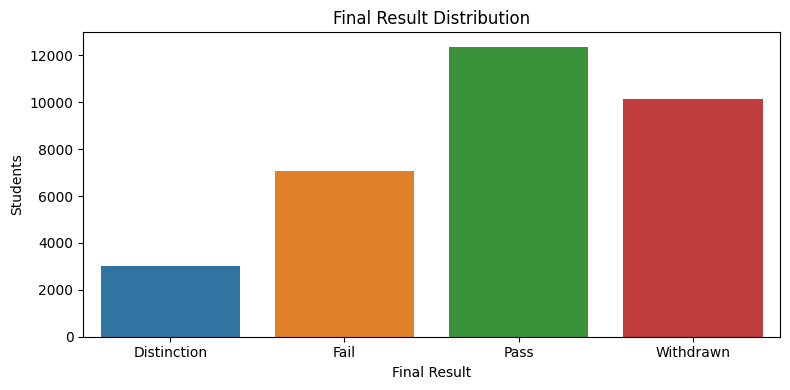

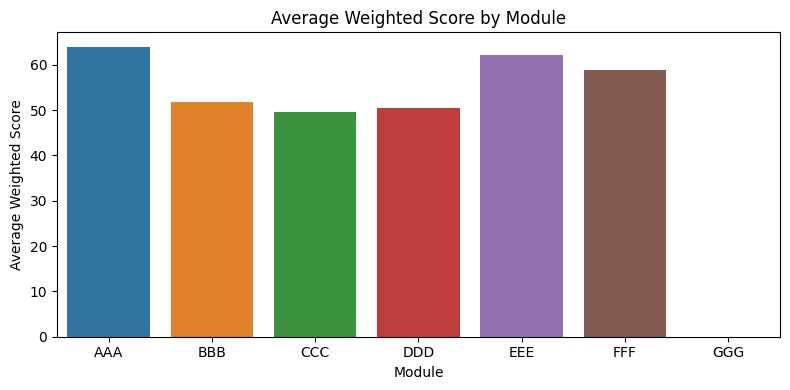

In [9]:
result_pdf = (
    student_profile
    .groupBy("final_result")
    .count()
    .orderBy("final_result")
    .toPandas()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=result_pdf, x="final_result", y="count", hue="final_result", legend=False)
plt.title("Final Result Distribution")
plt.xlabel("Final Result")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

module_pdf = spark.sql("""
    SELECT code_module, ROUND(AVG(weighted_avg_score), 2) AS avg_weighted_score
    FROM student_profile
    GROUP BY code_module
    ORDER BY code_module
""").toPandas()

plt.figure(figsize=(8, 4))
sns.barplot(data=module_pdf, x="code_module", y="avg_weighted_score", hue="code_module", legend=False)
plt.title("Average Weighted Score by Module")
plt.xlabel("Module")
plt.ylabel("Average Weighted Score")
plt.tight_layout()
plt.show()

## Q6. ETL Pipeline Development

In [10]:
activity_features = (
    student_vle
    .groupBy(*keys)
    .agg(
        F.sum("sum_click").alias("total_clicks_raw"),
        F.countDistinct("date").alias("active_days"),
        F.min("date").alias("first_activity_day"),
        F.max("date").alias("last_activity_day"),
    )
)

etl_df = (
    student_base
    .join(score_by_student, on=keys, how="left")
    .join(activity_features, on=keys, how="left")
    .withColumn("days_registered_before_start", -F.col("date_registration"))
    .withColumn("was_unregistered", F.when(F.col("date_unregistration").isNotNull(), 1).otherwise(0))
    .withColumn("pass_label", F.when(F.col("final_result").isin("Pass", "Distinction"), 1.0).otherwise(0.0))
    .fillna({
        "avg_score": 0.0,
        "weighted_avg_score": 0.0,
        "assessments_submitted": 0,
        "banked_assessments": 0,
        "total_clicks_raw": 0,
        "active_days": 0,
        "first_activity_day": 0,
        "last_activity_day": 0,
        "days_registered_before_start": 0,
        "module_presentation_length": 0,
    })
    .withColumn("avg_clicks_per_day", F.when(F.col("active_days") > 0, F.col("total_clicks_raw") / F.col("active_days")).otherwise(0.0))
    .withColumnRenamed("total_clicks_raw", "total_clicks")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("ETL feature table rows:", etl_df.count())
etl_df.select(
    "code_module", "code_presentation", "id_student", "gender", "highest_education",
    "num_of_prev_attempts", "studied_credits", "days_registered_before_start",
    "avg_score", "weighted_avg_score", "total_clicks", "active_days",
    "avg_clicks_per_day", "was_unregistered", "final_result", "pass_label"
).show(10, truncate=False)

print("Label distribution")
etl_df.groupBy("pass_label", "final_result").count().orderBy("pass_label", "final_result").show(truncate=False)

feature_output = OUTPUT_DIR / "student_features.csv"
etl_df.toPandas().to_csv(feature_output, index=False)
print("Saved ETL feature table to:", feature_output)

ETL feature table rows: 32593


+-----------+-----------------+----------+------+---------------------+--------------------+---------------+----------------------------+---------+------------------+------------+-----------+------------------+----------------+------------+----------+
|code_module|code_presentation|id_student|gender|highest_education    |num_of_prev_attempts|studied_credits|days_registered_before_start|avg_score|weighted_avg_score|total_clicks|active_days|avg_clicks_per_day|was_unregistered|final_result|pass_label|
+-----------+-----------------+----------+------+---------------------+--------------------+---------------+----------------------------+---------+------------------+------------+-----------+------------------+----------------+------------+----------+
|AAA        |2013J            |11391     |M     |HE Qualification     |0                   |240            |159                         |82.0     |82.4              |934         |40         |23.35             |0               |Pass        |1.0 

+----------+------------+-----+
|pass_label|final_result|count|
+----------+------------+-----+
|0.0       |Fail        |7052 |
|0.0       |Withdrawn   |10156|
|1.0       |Distinction |3024 |
|1.0       |Pass        |12361|
+----------+------------+-----+



Saved ETL feature table to: C:\Users\15dha\OneDrive\Desktop\case_study\outputs\student_features.csv


## Q7. Machine Learning Implementation

In [11]:
categorical_cols = [
    "code_module", "code_presentation", "gender", "region", "highest_education",
    "imd_band", "age_band", "disability",
]

numeric_cols = [
    "num_of_prev_attempts", "studied_credits", "module_presentation_length",
    "days_registered_before_start", "was_unregistered", "avg_score",
    "weighted_avg_score", "assessments_submitted", "banked_assessments",
    "total_clicks", "active_days", "avg_clicks_per_day",
]

model_df = etl_df.select("pass_label", *categorical_cols, *numeric_cols).fillna("Unknown", subset=categorical_cols).fillna(0, subset=numeric_cols)

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_vec")
    for col in categorical_cols
]

assembler = VectorAssembler(
    inputCols=[f"{col}_vec" for col in categorical_cols] + numeric_cols,
    outputCol="features",
    handleInvalid="keep",
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="pass_label",
    maxIter=30,
    regParam=0.01,
)

pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])
model = pipeline.fit(train_df)
pred = model.transform(test_df).persist(StorageLevel.MEMORY_AND_DISK)

binary_eval = BinaryClassificationEvaluator(labelCol="pass_label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
acc_eval = MulticlassClassificationEvaluator(labelCol="pass_label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="pass_label", predictionCol="prediction", metricName="f1")

auc = binary_eval.evaluate(pred)
accuracy = acc_eval.evaluate(pred)
f1 = f1_eval.evaluate(pred)

print("Model: Spark ML Logistic Regression")
print("Target: pass_label = 1 for Pass/Distinction, 0 for Fail/Withdrawn")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

print("Confusion matrix")
pred.groupBy("pass_label", "prediction").count().orderBy("pass_label", "prediction").show()

print("Sample predictions")
pred.select("pass_label", "prediction", "probability", *numeric_cols[:5]).show(10, truncate=False)

import json

metrics_output = OUTPUT_DIR / "model_metrics.json"
metrics = {
    "model": "Spark ML Logistic Regression",
    "target": "pass_label",
    "auc": float(auc),
    "accuracy": float(accuracy),
    "f1": float(f1),
}
with open(metrics_output, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

pred_output = OUTPUT_DIR / "sample_predictions.csv"
pred.select("pass_label", "prediction", "probability", *numeric_cols[:5]).limit(100).toPandas().to_csv(pred_output, index=False)

print("Saved model metrics to:", metrics_output)
print("Saved sample predictions to:", pred_output)
print("Spark model object is trained in memory in this notebook. File-based Spark model saving was skipped because this Windows setup does not provide Hadoop winutils/HADOOP_HOME.")

Train rows: 26240


Test rows: 6353


Model: Spark ML Logistic Regression
Target: pass_label = 1 for Pass/Distinction, 0 for Fail/Withdrawn
AUC: 0.9706
Accuracy: 0.9142
F1 Score: 0.9142
Confusion matrix


+----------+----------+-----+
|pass_label|prediction|count|
+----------+----------+-----+
|       0.0|       0.0| 2936|
|       0.0|       1.0|  400|
|       1.0|       0.0|  145|
|       1.0|       1.0| 2872|
+----------+----------+-----+

Sample predictions


+----------+----------+------------------------------------------+--------------------+---------------+--------------------------+----------------------------+----------------+
|pass_label|prediction|probability                               |num_of_prev_attempts|studied_credits|module_presentation_length|days_registered_before_start|was_unregistered|
+----------+----------+------------------------------------------+--------------------+---------------+--------------------------+----------------------------+----------------+
|0.0       |1.0       |[0.061120015703384566,0.9388799842966155] |0                   |60             |268                       |102                         |0               |
|0.0       |1.0       |[0.496513287931641,0.503486712068359]     |0                   |60             |268                       |24                          |0               |
|0.0       |0.0       |[0.6294817788566696,0.37051822114333044]  |0                   |120            |268         

Saved model metrics to: C:\Users\15dha\OneDrive\Desktop\case_study\outputs\model_metrics.json
Saved sample predictions to: C:\Users\15dha\OneDrive\Desktop\case_study\outputs\sample_predictions.csv
Spark model object is trained in memory in this notebook. File-based Spark model saving was skipped because this Windows setup does not provide Hadoop winutils/HADOOP_HOME.


In [12]:
spark.stop()
print("Notebook completed successfully for Q1 to Q7.")

Notebook completed successfully for Q1 to Q7.
